In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import matplotlib.patches as mpl_patches
from scipy.stats import mannwhitneyu
import matplotlib.ticker as ticker

In [11]:
df=pd.read_table('DH_leaf_B_wGenotype.txt',header=None)
df=df.rename(columns={0:"Seq_ID", 1:"B", 2:"BOR1", 3:"BOR2"})
df

,Seq_ID,B,BOR1,BOR2
0,4200_AB,63.366414,0,0
1,4200_AC,71.625178,0,0
2,4200_AE,72.577404,0,0
3,4200_AH,117.921445,1,0
4,4200_AI,66.095645,0,0
...,...,...,...,...
162,5019_V,79.889498,0,0
163,5019_W,75.601097,0,0
164,5019_X,70.472265,0,0
165,5019_Y,83.452613,.,0


In [12]:
df=df.loc[df['BOR1'] != '.']
df=df.loc[df['BOR2'] != '.']
df

,Seq_ID,B,BOR1,BOR2
0,4200_AB,63.366414,0,0
1,4200_AC,71.625178,0,0
2,4200_AE,72.577404,0,0
3,4200_AH,117.921445,1,0
4,4200_AI,66.095645,0,0
...,...,...,...,...
161,5019_U,129.900217,1,0
162,5019_V,79.889498,0,0
163,5019_W,75.601097,0,0
164,5019_X,70.472265,0,0


In [13]:
df['BOR1-BOR2']=df['BOR1']+'-'+df['BOR2']
df

,Seq_ID,B,BOR1,BOR2,BOR1-BOR2
0,4200_AB,63.366414,0,0,0-0
1,4200_AC,71.625178,0,0,0-0
2,4200_AE,72.577404,0,0,0-0
3,4200_AH,117.921445,1,0,1-0
4,4200_AI,66.095645,0,0,0-0
...,...,...,...,...,...
161,5019_U,129.900217,1,0,1-0
162,5019_V,79.889498,0,0,0-0
163,5019_W,75.601097,0,0,0-0
164,5019_X,70.472265,0,0,0-0


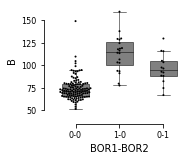

In [21]:
boxprops = {'edgecolor': 'black', 'linewidth': 0.5, 'facecolor': 'grey'}
lineprops = {'color': 'k', 'linewidth': 0.5}
boxplot_kwargs = dict({'boxprops': boxprops, 'medianprops': lineprops,
                       'whiskerprops': lineprops, 'capprops': lineprops,
                       'width': 0.6})
@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(6*cm,5*cm))
ax=sns.boxplot(x='BOR1-BOR2', 
            y='B',
            color='grey',
            data=df,
            linewidth=1.5,
            fliersize=0,
            **boxplot_kwargs)
ax=sns.swarmplot(x='BOR1-BOR2', 
            y='B',
            color='0',
            data=df,
            s=2)
sns.despine(trim=True,offset=10)
plt.tick_params(labelsize=8)
plt.savefig("Fig4f.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [18]:
mannwhitneyu(df[df['BOR1-BOR2'] == '0-0'].B,df[df['BOR1-BOR2'] == '1-0'].B)

MannwhitneyuResult(statistic=113.0, pvalue=3.8214254996294674e-11)

In [22]:
mannwhitneyu(df[df['BOR1-BOR2'] == '0-0'].B,df[df['BOR1-BOR2'] == '0-1'].B)

MannwhitneyuResult(statistic=220.0, pvalue=2.4840706983880443e-06)